In [7]:
# ========================================
# 1. Importação de pacotes
# ========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
#sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# ========================================
# 2. Carregar dados
# ========================================
file_path = "dados1.csv"   # coloque o caminho do arquivo aqui
df = pd.read_csv(file_path, delimiter=";")

# ========================================
# 3. Pré-processamento
# ========================================
# Substituir vírgula decimal por ponto
df = df.map(lambda x: str(x).replace(",", ".") if isinstance(x, str) else x)

# Converter colunas numéricas
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass  # mantém texto se não for numérico

FileNotFoundError: [Errno 2] No such file or directory: 'dados1.xlsx)'

In [2]:
# ========================================
# 4. Explorar dados
# ========================================
#print(df.head())
df.describe()

,Horas,"H_L1(a = 2,26cm2)","H_L2(a = 4,71cm2)","H_L3(a = 8,29cm2)",HR,Vento,Rad,Temp_foco,Temp_biomassa,Temp_amb
count,6.000000e+01,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000,60.000000
mean,1.759838e+18,28.340000,31.641667,37.306667,22.933333,2.132000,842.881333,59.253500,57.17200,30.818667
std,6.156574e+12,14.792316,15.039229,11.287654,11.043622,2.414871,96.364859,70.550184,33.43635,4.497626
min,1.759829e+18,8.300000,8.300000,8.800000,10.000000,0.200000,566.180000,0.000000,22.00000,22.000000
25%,1.759834e+18,8.300000,9.875000,31.600000,10.000000,0.400000,790.180000,0.000000,31.81750,26.630000
50%,1.759838e+18,32.100000,38.400000,42.950000,22.500000,1.200000,869.280000,16.940000,37.27500,31.795000
75%,1.759842e+18,42.200000,43.825000,45.500000,32.000000,3.240000,910.670000,128.115000,77.22000,34.100000
max,1.759852e+18,45.500000,46.000000,46.000000,42.000000,7.940000,960.930000,249.360000,135.87000,37.600000


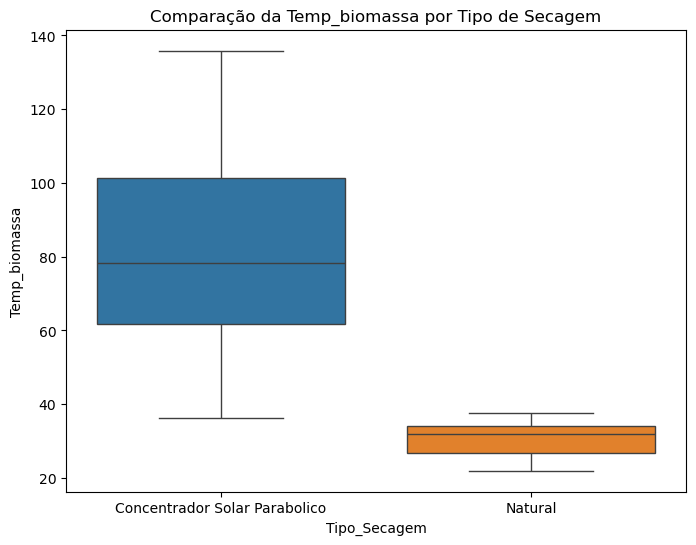

In [9]:
# ========================================
# 8. Comparação por Tipo de Secagem
# ========================================
plt.figure(figsize=(8,6))
sns.boxplot(x="Tipo_Secagem", y="Temp_biomassa", data=df, hue = 'Tipo_Secagem')
plt.title("Comparação da Temp_biomassa por Tipo de Secagem")
plt.show()

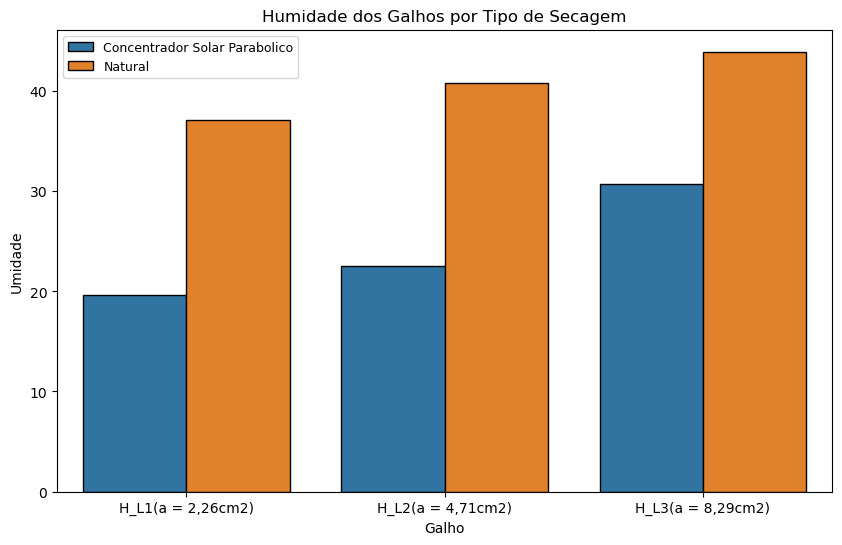

In [10]:
# Umidade média dos galhos por tipo de secagem
plt.figure(figsize=(10,6))
umidades = ["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]
df_melt = df.melt(id_vars="Tipo_Secagem", value_vars=umidades, var_name="Galho", value_name="Umidade")

sns.barplot(x="Galho", y="Umidade", hue="Tipo_Secagem", data=df_melt, errorbar=None, edgecolor = 'black')

plt.title("Humidade dos Galhos por Tipo de Secagem")
plt.legend(loc='upper left', fontsize=9)
plt.show()

# Novos Graficos

In [4]:
# 4. Separar dados por tipo de secagem
# ========================================
df_natural = df[df["Tipo_Secagem"] == "Natural"]
df_concentrador = df[df["Tipo_Secagem"] == "Concentrador Solar Parabolico"]
print(df_natural.columns)
print(df_concentrador.columns)

Index(['Horas', 'Tipo_Secagem', 'H_L1(a = 2,26cm2)', 'H_L2(a = 4,71cm2)',
       'H_L3(a = 8,29cm2)', 'HR', 'Vento', 'Rad', 'Temp_foco', 'Temp_biomassa',
       'Temp_amb'],
      dtype='object')
Index(['Horas', 'Tipo_Secagem', 'H_L1(a = 2,26cm2)', 'H_L2(a = 4,71cm2)',
       'H_L3(a = 8,29cm2)', 'HR', 'Vento', 'Rad', 'Temp_foco', 'Temp_biomassa',
       'Temp_amb'],
      dtype='object')


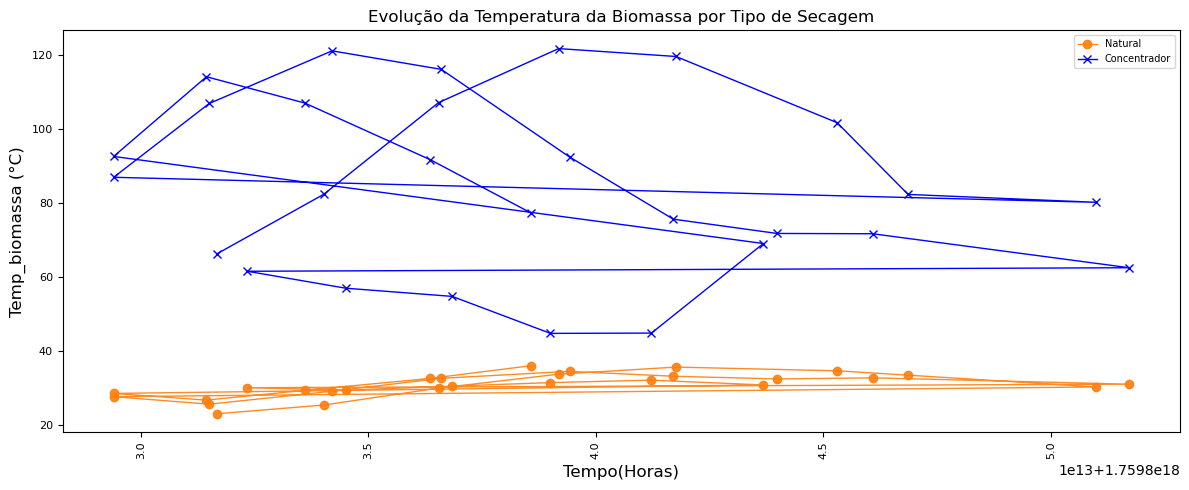

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Definir janela de suavização (ex: 3 pontos)
window = 3

# Suavizar Temp_biomassa para cada tipo de secagem
Temp_biomassa_natural_smooth = df_natural["Temp_biomassa"].rolling(window=window, center=True).mean()
Temp_biomassa_conc_smooth = df_concentrador["Temp_biomassa"].rolling(window=window, center=True).mean()

# Criar gráfico
plt.figure(figsize=(12,5))

plt.plot(df_natural["Horas"], Temp_biomassa_natural_smooth, label="Natural", marker='o',
         linewidth=1, color='C1', alpha=0.9)
plt.plot(df_concentrador["Horas"], Temp_biomassa_conc_smooth, label="Concentrador", marker='x',
         linewidth=1, color='b')

plt.yticks(rotation=0, fontsize=8)
plt.xticks(rotation=90, fontsize=8)
plt.xlabel("Tempo(Horas)", fontsize=12)
plt.ylabel("Temp_biomassa (°C)", fontsize=12)
plt.title("Evolução da Temperatura da Biomassa por Tipo de Secagem")
plt.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig("Fig2.png", dpi=300, bbox_inches='tight')
plt.show()

* ✅ Interpretação:O concentrador eleva a biomassa a mais de 130°C, enquanto a natural mal passa de 36°C. O calor intenso acelera a evaporação

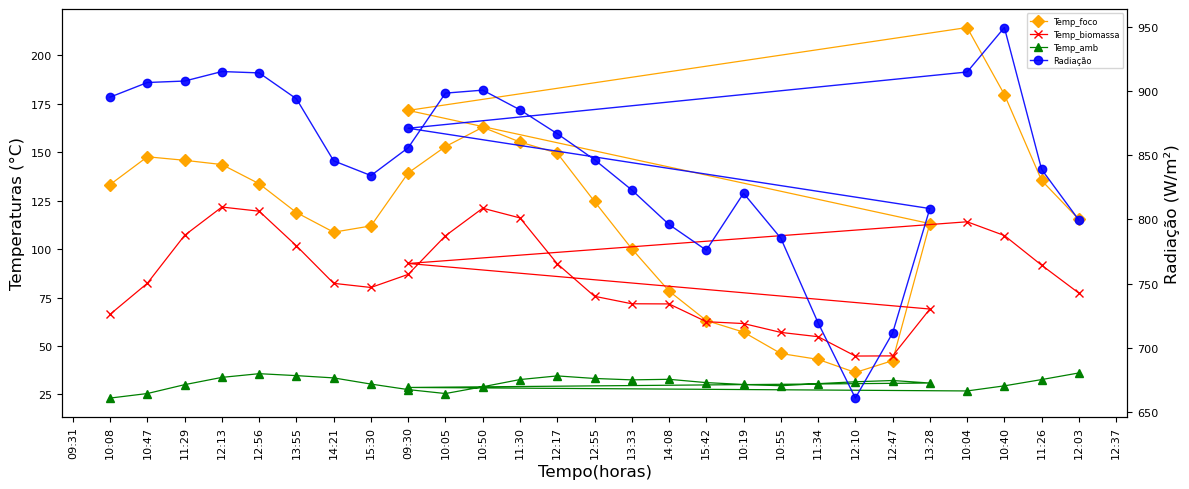

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
df_c = df_concentrador
df_n = df_natural

# Definir janela de suavização (ex: 3 pontos)
window = 3

# Suavizar os dados usando média móvel
Temp_foco_smooth = df_c["Temp_foco"].rolling(window=window, center=True).mean()
Temp_biomassa_smooth = df_c["Temp_biomassa"].rolling(window=window, center=True).mean()
Temp_amb_smooth = df_c["Temp_amb"].rolling(window=window, center=True).mean()
Rad_smooth = df_c["Rad"].rolling(window=window, center=True).mean()

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12,5))

# Plot Temperaturas suavizadas
ax1.plot(df_c["Horas"], Temp_foco_smooth, label="Temp_foco", color='orange', marker='D', linewidth=0.9)
ax1.plot(df_c["Horas"], Temp_biomassa_smooth, label="Temp_biomassa", color='red', marker='x', linewidth=0.9)
ax1.plot(df_c["Horas"], Temp_amb_smooth, label="Temp_amb", color='green', marker='^', linewidth=0.9)
ax1.tick_params(axis="y", labelcolor="black", labelsize=8)

ax1.set_xlabel("Tempo(horas)", fontsize=12)
ax1.set_ylabel("Temperaturas (°C)", fontsize=12 )
ax1.tick_params(axis='x', rotation=90, labelsize=8)

# Eixo secundário para Radiação suavizada
ax2 = ax1.twinx()
ax2.plot(df_c["Horas"], Rad_smooth, label="Radiação", color='blue', marker='o', linewidth=1, alpha=0.9)
ax2.set_ylabel("Radiação (W/m²)", fontsize=12,)
ax2.tick_params(axis="y", labelcolor="black", labelsize=8)

# Combinar legendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=6)

#plt.title("Temperaturas vs Radiação ")
plt.tight_layout()
fig.savefig("temperaturas_vs_rad.png", dpi=300)
plt.show()

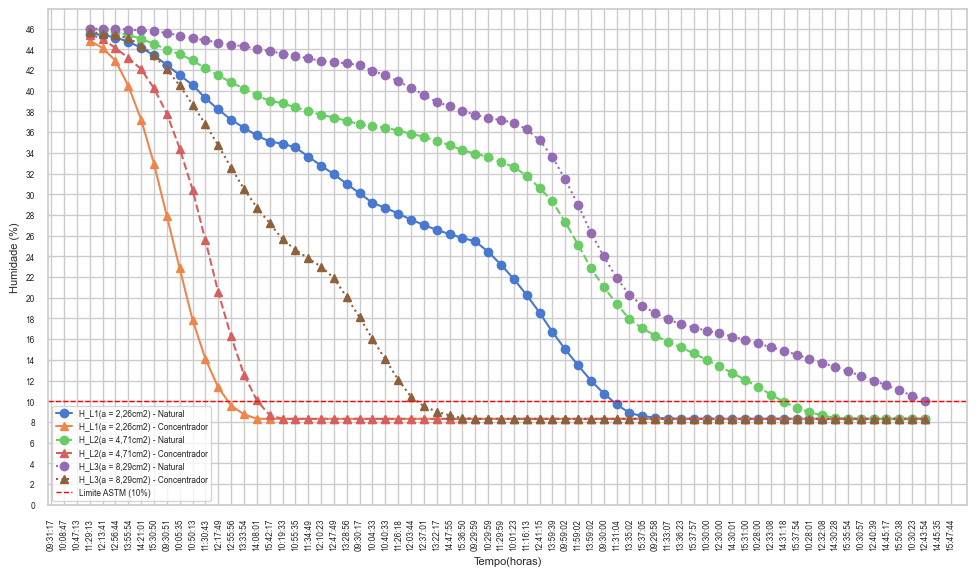

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Definir janela de suavização (ex: 3 pontos)
window = 6

galhos = ["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]

plt.figure(figsize=(10,6))

# Plot para cada galho e tipo de secagem suavizado
markers = {"Natural": "o", "Concentrador": "^"}
linestyles = {"H_L1(a = 2,26cm2)": "-", "H_L2(a = 4,71cm2)": "--", "H_L3(a = 8,29cm2)": ":"}

for galho in galhos:
    # Suavização média móvel
    natural_smooth = df_natural[galho].rolling(window=window, center=True).mean()
    conc_smooth = df_concentrador[galho].rolling(window=window, center=True).mean()
    
    # Natural
    plt.plot(df_natural["Horas"], natural_smooth, label=f"{galho} - Natural",
             marker=markers["Natural"], linestyle=linestyles[galho])
    # Concentrador
    plt.plot(df_concentrador["Horas"], conc_smooth, label=f"{galho} - Concentrador",
             marker=markers["Concentrador"], linestyle=linestyles[galho])

# Linha horizontal ASTM (umidade seca = 10%)
plt.axhline(y=10, color='red', linestyle='--', linewidth=1, label="Limite ASTM (10%)")

plt.xticks(rotation=90, fontsize=6)
plt.xlabel("Tempo(horas)", fontsize=8)
plt.ylabel("Humidade (%)", fontsize=8)

# Ajustar escala vertical de 5 em 5
plt.yticks(range(0, int(max(df_c[galhos].max().max(), 10))+ 2, 2), fontsize=6)

#plt.title("Comparação da Humidade dos Galhos - Natural vs Concentrador (Suavizado)")
plt.legend(fontsize=6, loc="lower left")
plt.tight_layout()
plt.savefig("Fig3.png", dpi=300, bbox_inches='tight')
plt.show()

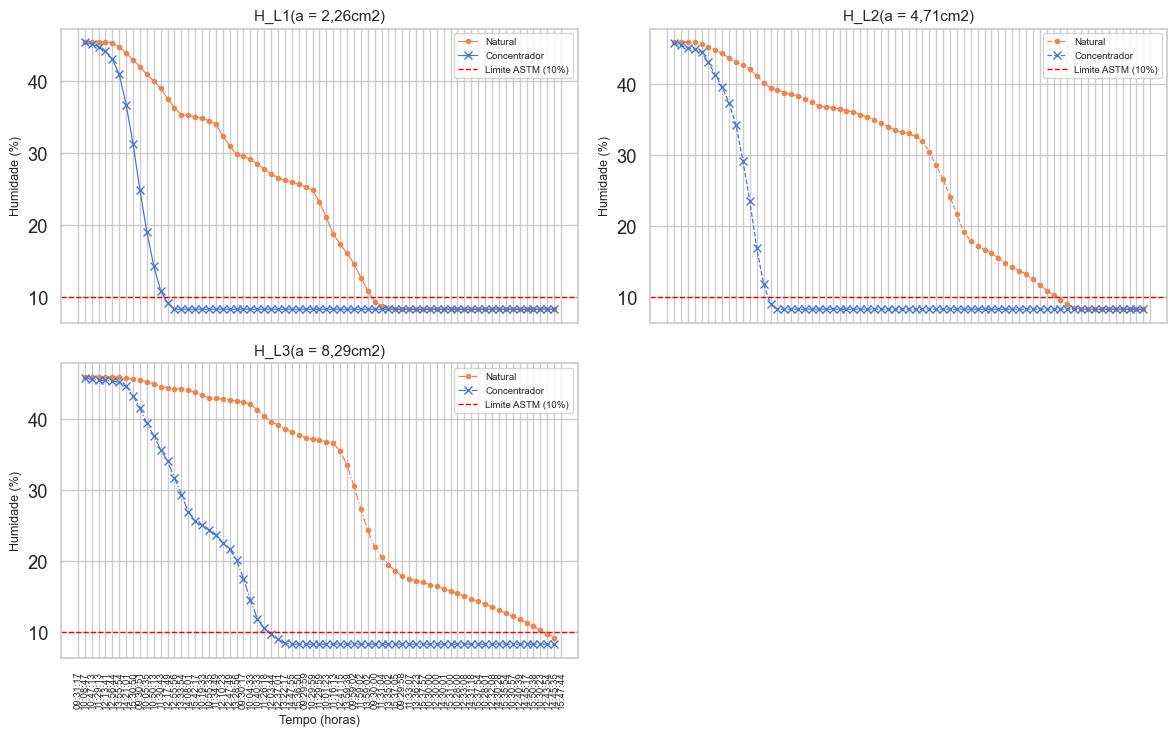

In [10]:
import matplotlib.pyplot as plt

# Definições
galhos = ["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]
markers = {"Natural": ".", "Concentrador": "x"}
linestyles = {
    "H_L1(a = 2,26cm2)": "-",
    "H_L2(a = 4,71cm2)": "--",
    "H_L3(a = 8,29cm2)": "-."
}
window = 3  # suavização média móvel

# Criar figura com 2 linhas e 2 colunas
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()  # transformar em lista para iterar facilmente

# Plotagem dos 3 galhos
for i, galho in enumerate(galhos):
    # Suavização média móvel
    natural_smooth = df_natural[galho].rolling(window=window, center=True).mean()
    conc_smooth = df_concentrador[galho].rolling(window=window, center=True).mean()
    
    # Plot Natural
    axes[i].plot(df_natural["Horas"], natural_smooth, label="Natural",
                 marker=markers["Natural"], linestyle=linestyles[galho], 
                 color='C1', linewidth=0.9)
    
    # Plot Concentrador
    axes[i].plot(df_concentrador["Horas"], conc_smooth, label="Concentrador",
                 marker=markers["Concentrador"], linestyle=linestyles[galho], 
                 color='b', linewidth=0.9)
    
    # Linha ASTM
    axes[i].axhline(y=10, color='red', linestyle='--', linewidth=1, label="Limite ASTM (10%)")
    
    # Configurações dos eixos
    axes[i].set_ylabel("Humidade (%)", fontsize=9)
    axes[i].set_title(galho, fontsize=11)
    axes[i].legend(fontsize=7, loc="upper right")
    axes[i].grid(True)

# Deixar o último espaço vazio (ou pode ser usado para legenda geral)
axes[-1].axis("off")

# Rótulo eixo X na última linha
for ax in axes[2:]:
    ax.set_xlabel("Tempo (horas)", fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=7)

# Título geral
#fig.suptitle("Comparação da Umidade dos Galhos - Natural vs Concentrador", 
             #fontsize=13, fontweight="bold", ha="center")

# Ajustar espaçamento
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Salvar e mostrar
plt.savefig("Fig4.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# Primeiro: corrigir NOMES das colunas (substituir vírgulas por pontos NOS NOMES)
df_natural = df[df["Tipo_Secagem"] == "Natural"]
df_concentrador = df[df["Tipo_Secagem"] == "Concentrador Solar Parabolico"]

In [12]:
df_concentrador.describe()

,"H_L1(a = 2,26cm2)","H_L2(a = 4,71cm2)","H_L3(a = 8,29cm2)",HR,Vento,Rad,Temp_foco,Temp_biomassa,Temp_amb
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,13.081690,14.291549,17.754930,24.577465,1.607183,807.117324,114.265352,82.925070,28.826901
std,11.526594,12.738880,13.855806,12.688197,1.844739,114.697773,42.298886,25.213328,4.321933
min,8.300000,8.300000,8.300000,10.000000,0.200000,426.650000,33.880000,36.180000,21.140000
25%,8.300000,8.300000,8.300000,12.500000,0.400000,774.270000,83.640000,64.575000,25.420000
50%,8.300000,8.300000,8.300000,22.000000,0.800000,834.130000,118.770000,76.820000,27.950000
75%,8.300000,8.300000,25.100000,32.000000,2.180000,893.670000,141.865000,98.600000,32.070000
max,45.500000,46.000000,46.000000,54.000000,7.940000,960.930000,249.360000,143.980000,37.940000


In [13]:
# ========================================
# 6. Calcular umidade média
# ========================================
# Agora os nomes das colunas estão corretos com ponto
df["Umidade_Media"] = df[["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]].mean(axis=1)
df_natural.loc[:, "Umidade_Media"] = df_natural[["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]].mean(axis=1)
df_concentrador.loc[:, "Umidade_Media"] = df_concentrador[["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]].mean(axis=1)

C:\Users\Miocha\AppData\Local\Temp\ipykernel_13096\1302645705.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_natural.loc[:, "Umidade_Media"] = df_natural[["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]].mean(axis=1)
C:\Users\Miocha\AppData\Local\Temp\ipykernel_13096\1302645705.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_concentrador.loc[:, "Umidade_Media"] = df_concentrador[["H_L1(a = 2,26cm2)", "H_L2(a = 4,71cm2)", "H_L3(a = 8,29cm2)"]].mean(axis=1)


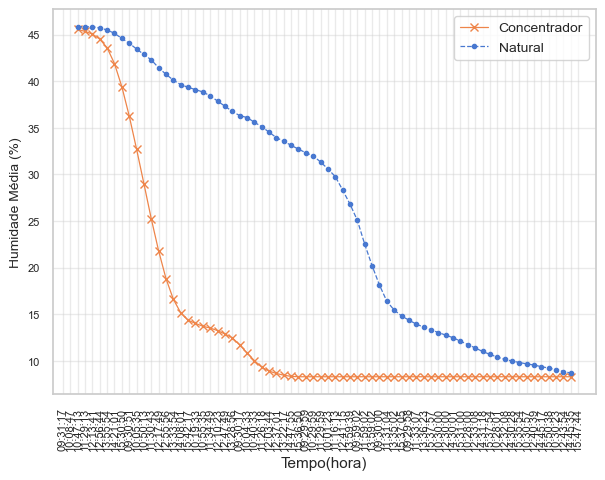

In [14]:
import matplotlib.pyplot as plt

# Suavização média móvel
window = 4  # pode ajustar: quanto maior, mais suave
umid_conc_smooth = df_concentrador["Umidade_Media"].rolling(window=window, center=True).mean()
umid_nat_smooth = df_natural["Umidade_Media"].rolling(window=window, center=True).mean()

plt.figure(figsize=(7,5))

# GRÁFICO SUAVIZADO
plt.plot(df_concentrador["Horas"], umid_conc_smooth, 
         marker="x", label="Concentrador", 
         color="C1", linewidth=0.9)

plt.plot(df_natural["Horas"], umid_nat_smooth, 
         marker=".", label="Natural", 
         color="b", linestyle="--", linewidth=0.9)


# Título e eixos
#plt.title("1. Redução de Humidade Media ", fontsize=10)
plt.xlabel("Tempo(hora)", fontsize=11)
plt.ylabel("Humidade Média (%)", fontsize=10)

# Ajuste do tamanho das labels dos ticks
plt.xticks(rotation=90, fontsize=8)  # eixo X
plt.yticks(fontsize=8)               # eixo Y

plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.savefig("Fig5.png", dpi=300, bbox_inches='tight')
plt.show()


* ✅ Interpretação:
A umidade cai de 45,5% para 8,3% em menos de 7 horas. A maior queda ocorre entre 10h e 13h, quando a radiação é mais intens

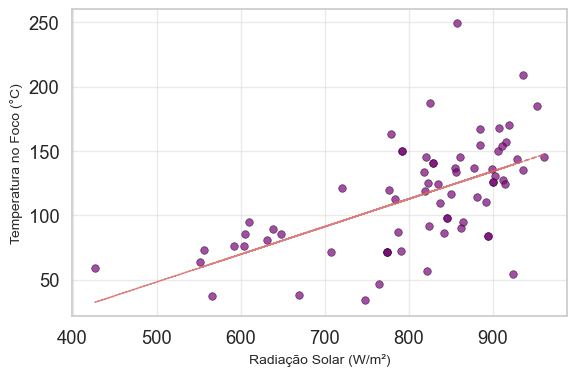

In [15]:
import numpy as np
# Gráfico 5: Radiação Solar vs. Temperatura no Foco (Concentrador)
plt.figure(figsize=(6, 4))
plt.scatter(df_concentrador["Rad"], df_concentrador["Temp_foco"],
            color="purple", alpha=0.7, s=30, edgecolors='k', linewidth=0.5)
z = np.polyfit(df_concentrador["Rad"], df_concentrador["Temp_foco"], 1)
p = np.poly1d(z)
plt.plot(df_concentrador["Rad"], p(df_concentrador["Rad"]), "r--", alpha=0.8, linewidth=1)

#plt.title("Radiação Solar vs. Temperatura no Foco", fontsize=10)
plt.xlabel("Radiação Solar (W/m²)",fontsize=10)
plt.ylabel("Temperatura no Foco (°C)", fontsize=10)
plt.grid(True, alpha=0.4)

# Calcular e exibir correlação
corr_rad_temp = df_concentrador["Rad"].corr(df_concentrador["Temp_foco"])
#plt.text(800, 100, fontsize=8, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("Fig8.png", dpi=300, bbox_inches='tight')
plt.show()

✅ Interpretação:
Correlação positiva forte (r ≈ 0.85): mais radiação → maior temperatura no foco. Sistema altamente eficiente sob sol pleno.

C:\Users\Miocha\AppData\Local\Temp\ipykernel_13096\3155477196.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_natural.loc[:, "Faixa_HR"] = df_natural["HR"].apply(faixa_hr)
C:\Users\Miocha\AppData\Local\Temp\ipykernel_13096\3155477196.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_concentrador.loc[:, "Faixa_HR"] = df_concentrador["HR"].apply(faixa_hr)


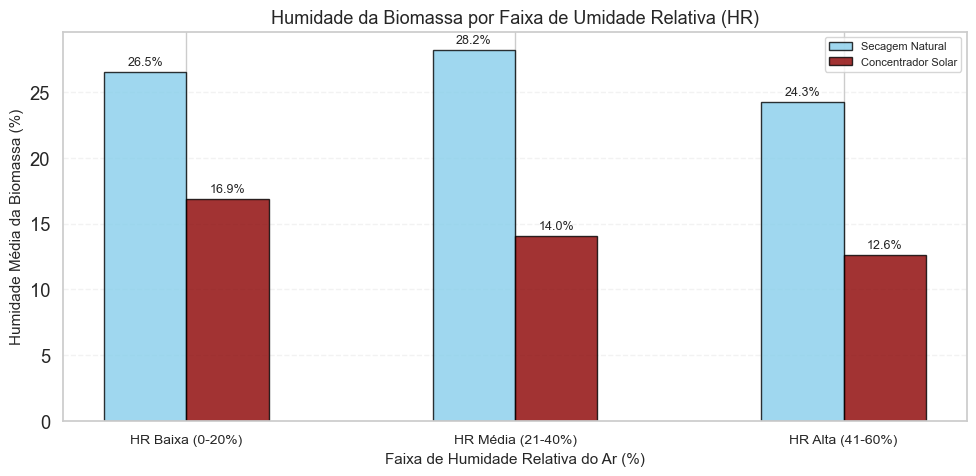

In [16]:
# ========================================
# GRÁFICO 6: Umidade da Biomassa por Faixa de HR (Gráfico de Barras)
# ========================================
import numpy as np
import matplotlib.pyplot as plt

# Função para categorizar HR
def faixa_hr(hr):
    if hr <= 20:
        return 'HR Baixa (0-20%)'
    elif hr <= 40:
        return 'HR Média (21-40%)'
    else:
        return 'HR Alta (41-60%)'

# Aplicar faixas de HR
df_natural.loc[:, "Faixa_HR"] = df_natural["HR"].apply(faixa_hr)
df_concentrador.loc[:, "Faixa_HR"] = df_concentrador["HR"].apply(faixa_hr)

# Calcular umidade média da biomassa por faixa e método
natural_hr = df_natural.groupby("Faixa_HR")["Umidade_Media"].mean()
conc_hr = df_concentrador.groupby("Faixa_HR")["Umidade_Media"].mean()

# Garantir que todas as faixas estejam presentes
faixas = ['HR Baixa (0-20%)', 'HR Média (21-40%)', 'HR Alta (41-60%)']
natural_vals = [natural_hr.get(f, np.nan) for f in faixas]
conc_vals = [conc_hr.get(f, np.nan) for f in faixas]

# Substituir NaN por 0 para visualização
natural_vals = [v if not np.isnan(v) else 0 for v in natural_vals]
conc_vals = [v if not np.isnan(v) else 0 for v in conc_vals]

# Plotar barras agrupadas
x = np.arange(len(faixas))  # posição das faixas
largura = 0.25  # largura menor das barras

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - largura/2, natural_vals, largura, label='Secagem Natural', 
                color='skyblue', edgecolor='black', alpha=0.8)
bars2 = plt.bar(x + largura/2, conc_vals, largura, label='Concentrador Solar', 
                color='darkred', edgecolor='black', alpha=0.8)

# Títulos e rótulos
plt.title("Humidade da Biomassa por Faixa de Umidade Relativa (HR)", 
          fontsize=13)
plt.xlabel("Faixa de Humidade Relativa do Ar (%)", fontsize=11)
plt.ylabel("Humidade Média da Biomassa (%)", fontsize=11)
plt.xticks(x, faixas, fontsize=10)
plt.legend(loc='upper right', fontsize=8)

# Adicionar valores nas barras (um pouco menores para suavizar)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # só mostra se houver valor
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                     f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Grid mais suave
plt.grid(True, axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()


Na secagem natural, a umidade da biomassa permanece alta quando o ar é úmido (alta HR).
No concentrador, mesmo com HR alta, a umidade cai rapidamente devido ao calor.
Em HR baixa, o concentrador é muito mais eficaz — atinge umidade <15%.
O gráfico mostra claramente que o concentrador reduz a dependência da condição climática

✅ Interpretação:
Leve correlação positiva: vento ajuda a remover ar úmido, mas efeito é limitado sem calor. Não compensa a falta de temperatura.

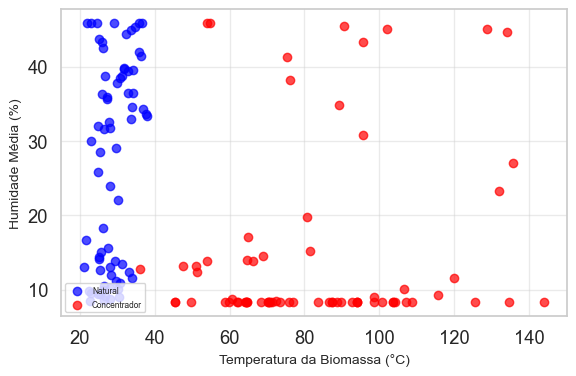

In [17]:
plt.figure(figsize=(6, 4))
plt.scatter(df_natural["Temp_biomassa"], df_natural["Umidade_Media"],
            color="blue", label="Natural", alpha=0.7)

plt.scatter(df_concentrador["Temp_biomassa"], df_concentrador["Umidade_Media"],
            color="red", label="Concentrador", alpha=0.7)

#plt.title("Temperatura da Biomassa vs. Umidade",fontsize=10 )
plt.xlabel("Temperatura da Biomassa (°C)", fontsize=10)
plt.ylabel("Humidade Média (%)", fontsize=10)
plt.legend( loc='lower left', fontsize=6)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("Fig9.png", dpi=300, bbox_inches='tight')
plt.show()

✅ Interpretação:
Clara correlação negativa: mais calor → menos umidade.
O concentrador opera em altas temperaturas com baixa umidade final.

✅ Interpretação:

Na secagem natural, mais vento e menos HR ajudam um pouco.
No concentrador, a redução é alta mesmo com baixo vento e alta HR.
→ O sistema não depende das condições climáticas

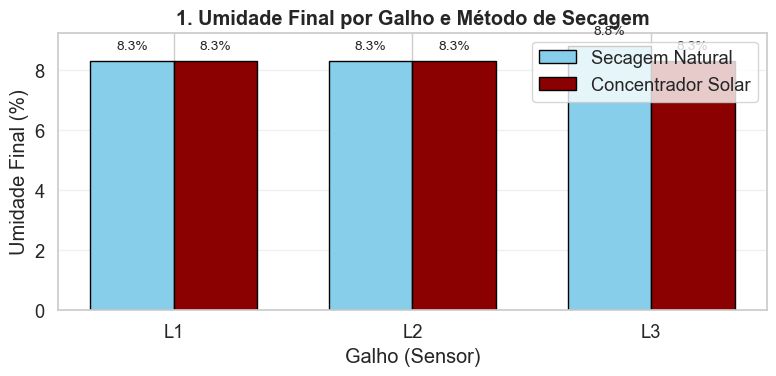

In [18]:
# ========================================
# GRÁFICO 1: Umidade Final por Método e por Galho
# ========================================
# Selecionar a última medição de cada método
ultimo_natural = df_natural.iloc[-1]
ultimo_concentrador = df_concentrador.iloc[-1]

# Dados para o gráfico
galhos = ['L1', 'L2', 'L3']
umid_natural = [
    ultimo_natural['H_L1(a = 2,26cm2)'],
    ultimo_natural['H_L2(a = 4,71cm2)'],
    ultimo_natural['H_L3(a = 8,29cm2)']
]
umid_conc = [
    ultimo_concentrador['H_L1(a = 2,26cm2)'],
    ultimo_concentrador['H_L2(a = 4,71cm2)'],
    ultimo_concentrador['H_L3(a = 8,29cm2)']
]

# Posições no eixo X
x = np.arange(len(galhos))
largura = 0.35

plt.figure(figsize=(8, 4))
bars1 = plt.bar(x - largura/2, umid_natural, largura, label='Secagem Natural', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + largura/2, umid_conc, largura, label='Concentrador Solar', color='darkred', edgecolor='black')

# Rótulos
plt.title("1. Umidade Final por Galho e Método de Secagem", fontweight='bold')
plt.xlabel("Galho (Sensor)")
plt.ylabel("Umidade Final (%)")
plt.xticks(x, galhos)
plt.legend()

# Adicionar valores nas barras
for bars, dados in [(bars1, umid_natural), (bars2, umid_conc)]:
    for bar, valor in zip(bars, dados):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{valor:.1f}%", ha='center', va='bottom', fontsize=10)

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico das correlacoes

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a matriz de correlação apenas para as variáveis numéricas
corr = df.select_dtypes(include="number").corr()

# Selecionar pares de variáveis com alta correlação (|r| > 0.7)
threshold = 0.7
corr_pairs = (
    corr.where(lambda x: abs(x) > threshold)
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Var1", "Var2", "Correlation"]
corr_pairs = corr_pairs[corr_pairs["Var1"] != corr_pairs["Var2"]].drop_duplicates()

#corr_pairs

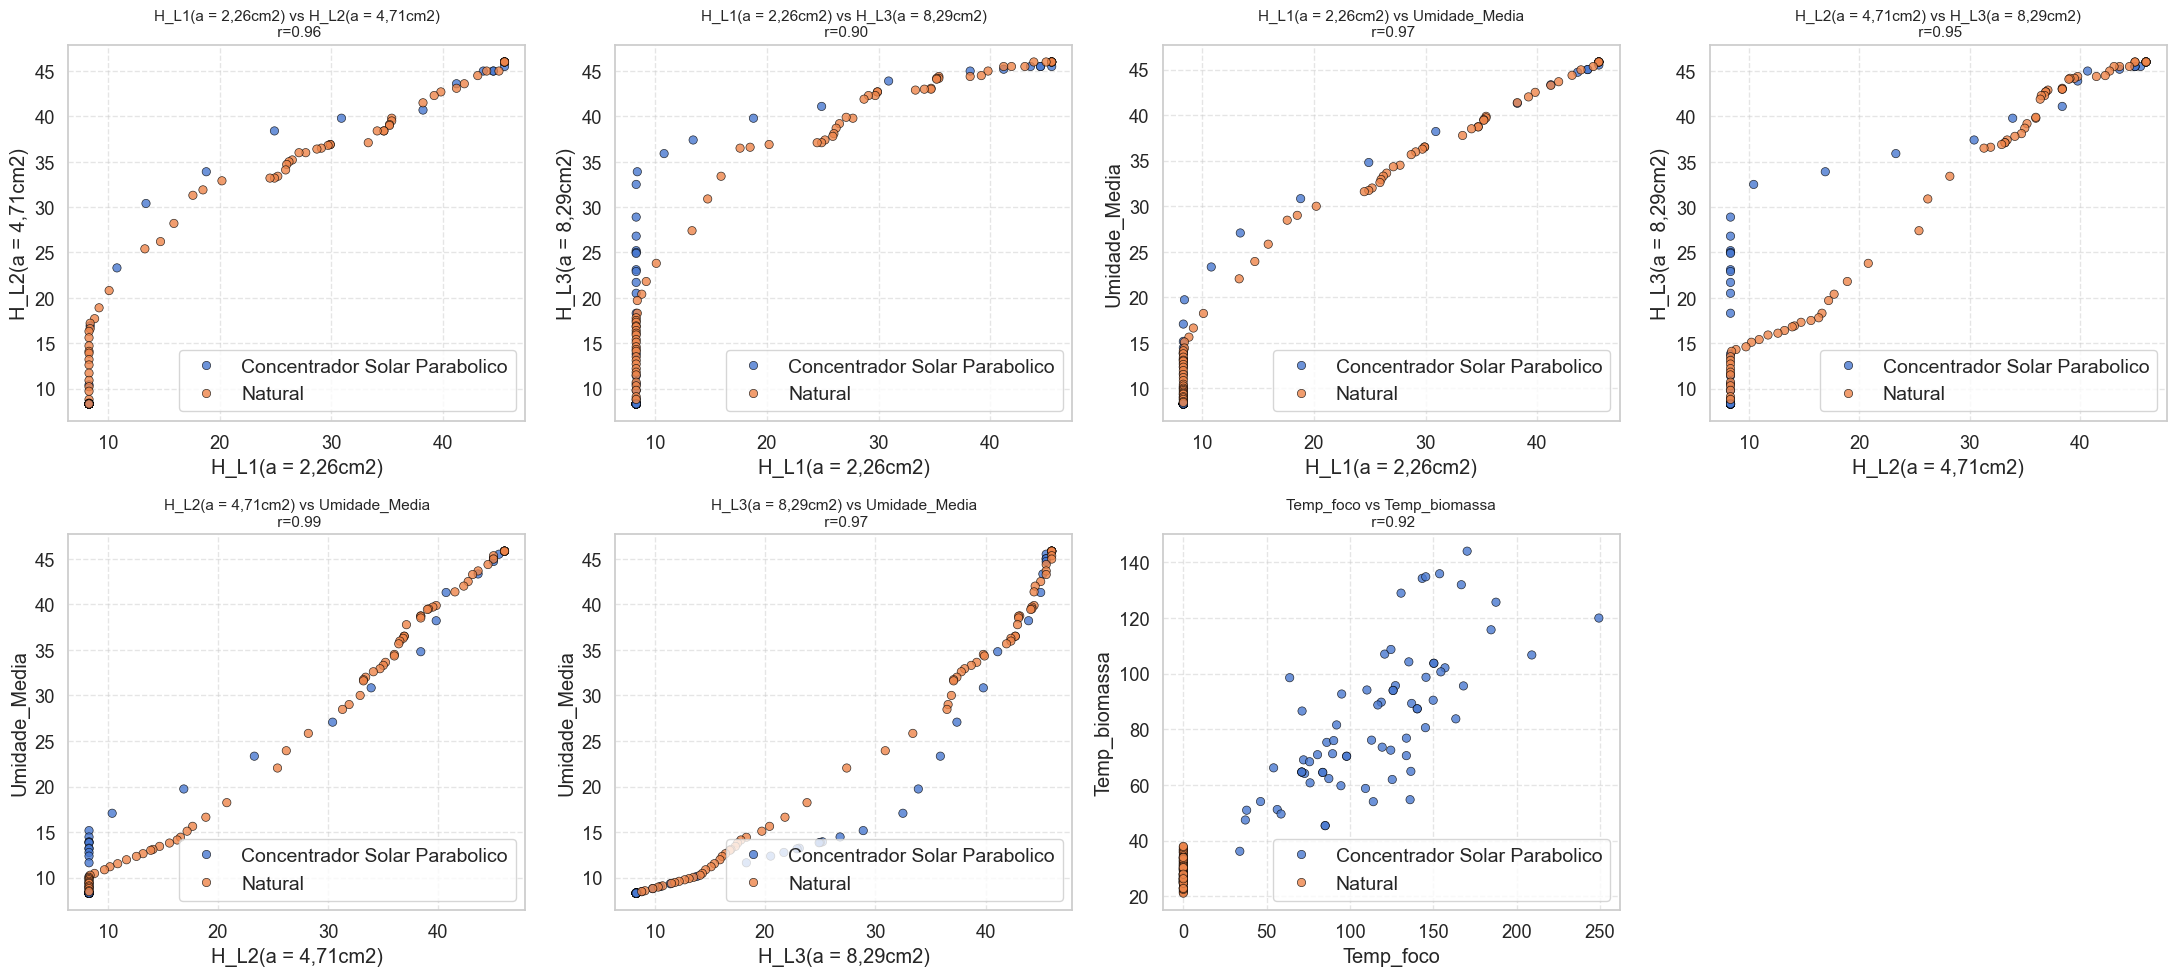

In [20]:
# Selecionar pares únicos
unique_pairs = []
seen = set()
for _, row in corr_pairs.iterrows():
    v1, v2 = row["Var1"], row["Var2"]
    if (v2, v1) not in seen:
        unique_pairs.append((v1, v2, row["Correlation"]))
        seen.add((v1, v2))

# Criar subplots em 2 linhas × 4 colunas
n = len(unique_pairs)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))  # bem visíveis
axes = axes.flatten()  # achatar matriz de eixos

for ax, (v1, v2, r) in zip(axes, unique_pairs):
    sns.scatterplot(data=df, x=v1, y=v2, hue="Tipo_Secagem", ax=ax, alpha=0.8, edgecolor = 'black')
    ax.set_title(f"{v1} vs {v2}\n r={r:.2f}", fontsize=11)
    ax.legend( loc='lower right', fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)

# Remover eixos vazios (se sobrar espaço na grade)
for j in range(len(unique_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Fig6.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Matriz de correlação
corr = df.corr(numeric_only=True)

# Transformar em pares
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Var1", "Var2", "Correlation"]

# Remover duplicados e self-correlations
corr_pairs = corr_pairs[corr_pairs["Var1"] != corr_pairs["Var2"]]
corr_pairs = corr_pairs.drop_duplicates(subset=["Correlation"])

# Selecionar fracas negativas (ex: -0.4 < r < -0.1)
weak_negatives = corr_pairs[(corr_pairs["Correlation"] < -0.1) & 
                            (corr_pairs["Correlation"] > -0.4)]


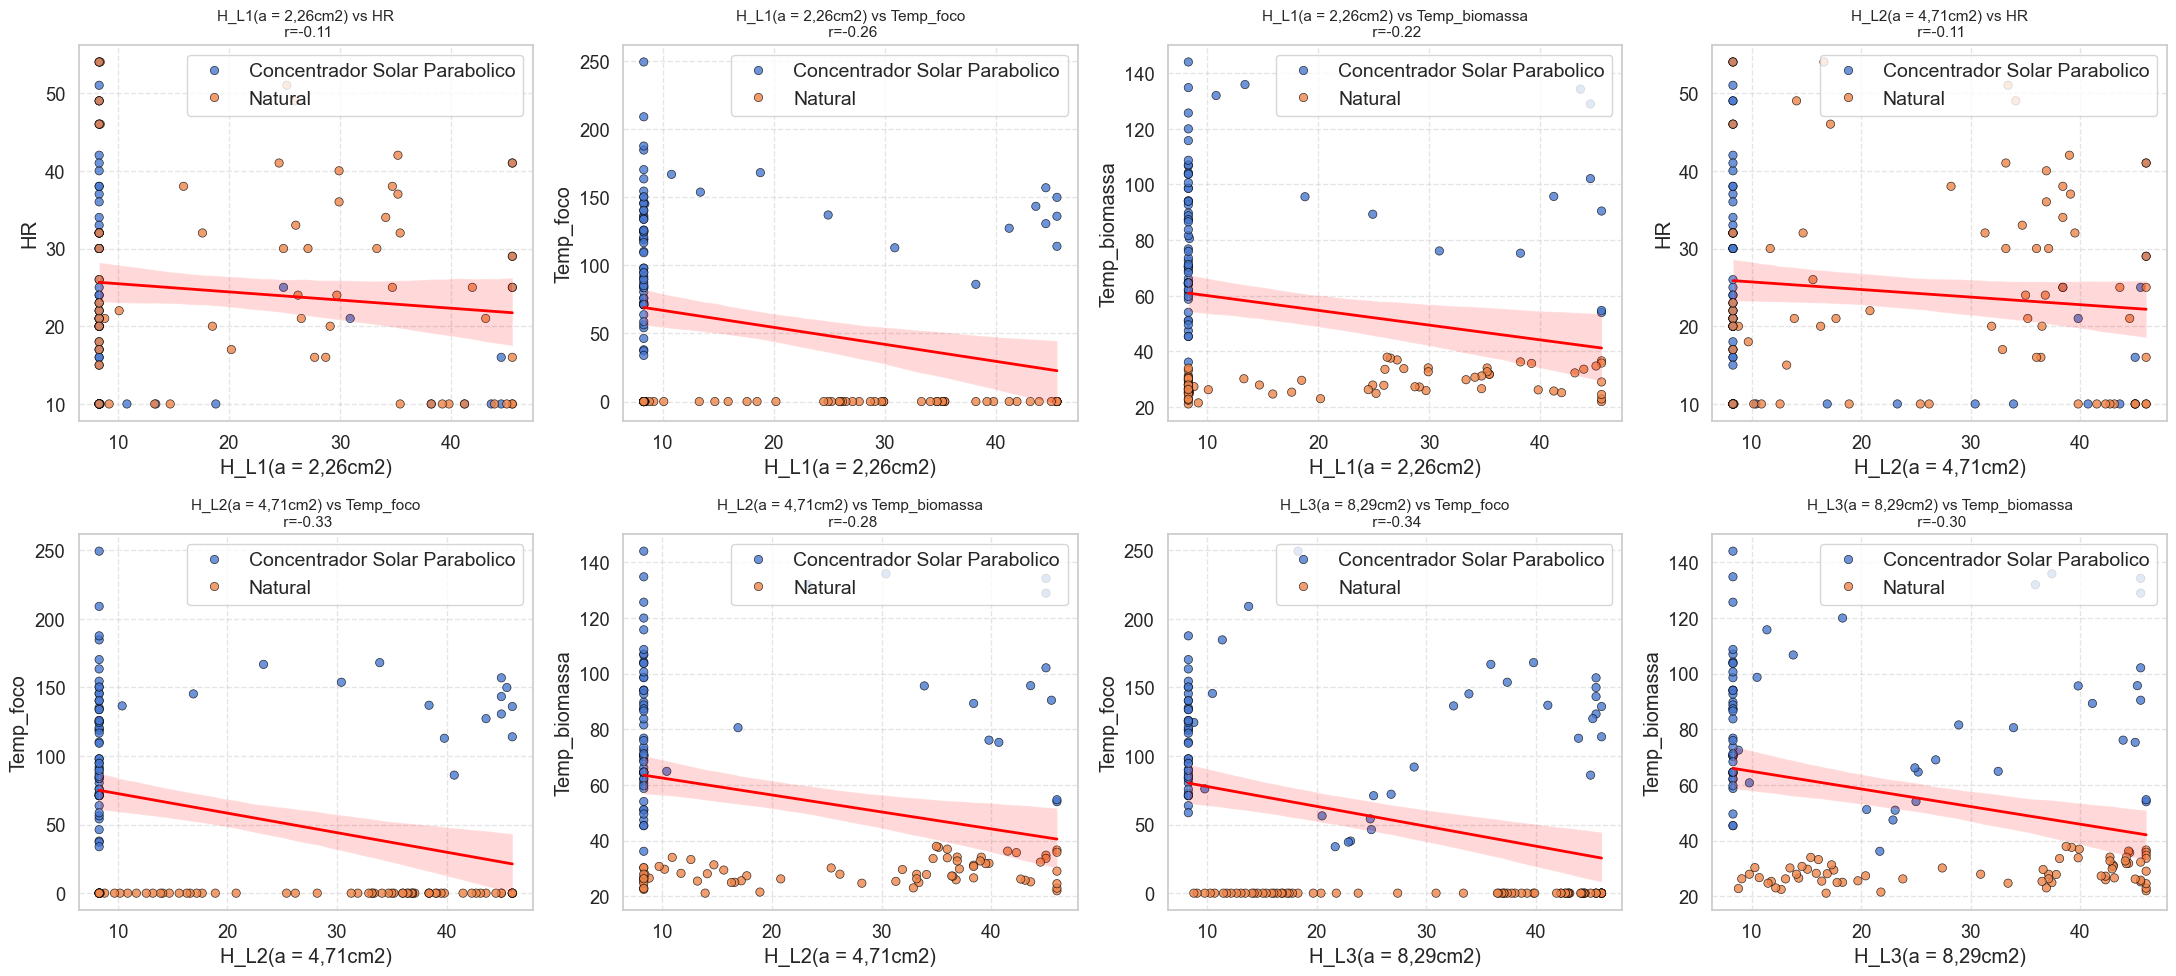

In [22]:
# Subplots
unique_pairs = []
seen = set()
for _, row in weak_negatives.iterrows():
    v1, v2 = row["Var1"], row["Var2"]
    if (v2, v1) not in seen:
        unique_pairs.append((v1, v2, row["Correlation"]))
        seen.add((v1, v2))

n = len(unique_pairs)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (v1, v2, r) in zip(axes, unique_pairs):
    sns.scatterplot(data=df, x=v1, y=v2, hue="Tipo_Secagem", ax=ax, alpha=0.8, edgecolor = 'black')
    sns.regplot(data=df, x=v1, y=v2, ax=ax, scatter=False, color="red", line_kws={"linewidth":2},)
    ax.set_title(f"{v1} vs {v2}\n r={r:.2f}", fontsize=11)
    ax.legend( loc='upper right', fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)

# Remover eixos extras
for j in range(len(unique_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Fig7.png", dpi=300, bbox_inches='tight')
plt.show()